# Walmart Sales Forecasting — PatchTST

**მოდელი:** PatchTST (Patch Time Series Transformer)  
**კატეგორია:** Deep Learning (Transformer-based)  
**ბიბლიოთეკა:** `neuralforecast` (Nixtla)  
**Logging:** WandB (project: `walmart-forecasting`)

**Runs:**
1. `PatchTST_Baseline` — default კონფიგი, patch_len=8
2. `PatchTST_LargerPatch` — patch_len=16, longer receptive field
3. `PatchTST_Deeper` — მეტი encoder layer, უფრო დიდი model dim
4. `PatchTST_Final` — საუკეთესო კონფიგი full train-ზე

**რატომ PatchTST:**

PatchTST-ის ორი ცენტრალური იდეა ("A Time Series is Worth 64 Words", ICLR 2023):

1. **Patching (Time series → tokens)** — time series-ს ცალკე "patches" ნაწილებად ჭრის, ისე როგორც Vision Transformer ჭრის სურათს patches-ად. თითო patch გახდება ერთი "token" transformer-ისთვის.
   - ამცირებს sequence length-ს → უფრო ეფექტური attention
   - ინახავს ლოკალურ სემანტიკურ ინფორმაციას თითო patch-ში
   
2. **Channel Independence** — multivariate time series-ის ნაცვლად, თითო channel (feature) ცალკე პროცესირდება იმავე გამოთანაბრებული (shared) weights-ით.
   - ამცირებს overfitting-ს
   - საშუალებას აძლევს ერთი მოდელი მრავალ time series-ს ისწავლოს

**შედარება N-BEATS-თან:**
- N-BEATS = pure feed-forward (residual blocks, basis expansion)
- PatchTST = transformer (attention-based, tokens = patches)
- ორივე global model — ერთი მოდელი ყველა (Store, Dept) კომბინაციისთვის


## 1. Setup

In [ ]:
!pip install neuralforecast wandb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 56.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MAE

import wandb
from pytorch_lightning.loggers import WandbLogger

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/walmart'
DATA_DIR = f'{PROJECT_DIR}/data'
MODELS_DIR = f'{PROJECT_DIR}/models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Data: {DATA_DIR}")
print(f"Models: {MODELS_DIR}")

Mounted at /content/drive
Data: /content/drive/MyDrive/walmart/data
Models: /content/drive/MyDrive/walmart/models


In [ ]:
# WandB login
from google.colab import userdata

try:
    wandb_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=wandb_key)
    print("WandB logged in")
except Exception as e:
    wandb.login()

WANDB_PROJECT = "walmart-forecasting"
print(f"WandB project: {WANDB_PROJECT}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zberi23 (zberi23_ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB logged in
WandB project: walmart-forecasting


## 2. მონაცემების მომზადება

PatchTST იმავე format-ს იყენებს რაც N-BEATS: `unique_id`, `ds`, `y` (long-format).

In [ ]:
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv.zip')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv.zip')

train_raw['Date'] = pd.to_datetime(train_raw['Date'])
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

print(f"Train: {train_raw.shape}")
print(f"Test:  {test_raw.shape}")

Train: (421570, 5)
Test:  (115064, 4)


In [ ]:
def to_patchtst_format(df, has_target=True):
    df = df.copy()
    df['unique_id'] = df['Store'].astype(str) + '_' + df['Dept'].astype(str)
    df = df.rename(columns={'Date': 'ds'})
    if has_target:
        df = df.rename(columns={'Weekly_Sales': 'y'})
        return df[['unique_id', 'ds', 'y']]
    return df[['unique_id', 'ds']]


train_pt = to_patchtst_format(train_raw, has_target=True)
test_pt = to_patchtst_format(test_raw, has_target=False)

# ფილტრი — მოკლე time series-ები pathTST-ს ეშლება
series_lengths = train_pt.groupby('unique_id').size()
MIN_LENGTH = 80  # PatchTST-ს უფრო გრძელი series სჭირდება patching-ის გამო
valid_ids = series_lengths[series_lengths >= MIN_LENGTH].index
train_pt = train_pt[train_pt['unique_id'].isin(valid_ids)].reset_index(drop=True)

print(f"Time series after filter (min length {MIN_LENGTH}): {train_pt['unique_id'].nunique()}")
print(f"Total rows: {len(train_pt)}")

Time series after filter (min length 80): 2934
Total rows: 412935


## 3. Train/Val Split + WMAE Metric

In [ ]:
def wmae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def evaluate_forecast(forecasts_df, val_df, train_raw_val, model_col='PatchTST'):
    merged = forecasts_df.merge(val_df, on=['unique_id', 'ds'], how='inner')

    train_raw_val_lookup = train_raw_val.copy()
    train_raw_val_lookup['unique_id'] = (
        train_raw_val_lookup['Store'].astype(str) + '_' + train_raw_val_lookup['Dept'].astype(str)
    )
    train_raw_val_lookup = train_raw_val_lookup.rename(columns={'Date': 'ds'})

    merged = merged.merge(
        train_raw_val_lookup[['unique_id', 'ds', 'IsHoliday']],
        on=['unique_id', 'ds'], how='left'
    )

    weights = np.where(merged['IsHoliday'] == True, 5, 1)
    return wmae(merged['y'].values, merged[model_col].values, weights)

In [ ]:
VAL_HORIZON = 12
train_pt_sorted = train_pt.sort_values(['unique_id', 'ds']).reset_index(drop=True)


def per_series_split(df, val_h):
    train_parts, val_parts = [], []
    for uid, group in df.groupby('unique_id'):
        group = group.sort_values('ds')
        if len(group) > val_h:
            train_parts.append(group.iloc[:-val_h])
            val_parts.append(group.iloc[-val_h:])
    return pd.concat(train_parts).reset_index(drop=True), pd.concat(val_parts).reset_index(drop=True)


train_split, val_split = per_series_split(train_pt_sorted, VAL_HORIZON)

val_dates = val_split['ds'].unique()
train_raw_val_period = train_raw[train_raw['Date'].isin(val_dates)]

print(f"Train split: {train_split.shape}, series: {train_split['unique_id'].nunique()}")
print(f"Val split:   {val_split.shape}, series: {val_split['unique_id'].nunique()}")

Train split: (377727, 3), series: 2934
Val split:   (35208, 3), series: 2934


## 4. Run 1 — `PatchTST_Baseline`

Default PatchTST კონფიგი:
- **input_size = 52** — 1 წელი წარსული (patchTST-ს გრძელი context უნდა)
- **patch_len = 8** — 8 კვირიანი patches
- **stride = 8** — non-overlapping patches
- **encoder_layers = 3** — 3 transformer encoder blocks
- **d_model = 128** — hidden dimension

In [ ]:
H = VAL_HORIZON  # forecast horizon = 12

BASELINE_CONFIG = {
    'h': H,
    'input_size': 52,
    'patch_len': 8,
    'stride': 8,
    'encoder_layers': 3,
    'n_heads': 4,
    'hidden_size': 128,
    'linear_hidden_size': 256,
    'dropout': 0.1,
    'max_steps': 500,
    'learning_rate': 1e-3,
    'batch_size': 32,
}

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="PatchTST_Baseline",
    config=BASELINE_CONFIG,
    reinit=True,
    tags=['patchtst', 'baseline']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="PatchTST_Baseline", experiment=run)

model_baseline = PatchTST(
    h=H,
    input_size=BASELINE_CONFIG['input_size'],
    patch_len=BASELINE_CONFIG['patch_len'],
    stride=BASELINE_CONFIG['stride'],
    encoder_layers=BASELINE_CONFIG['encoder_layers'],
    n_heads=BASELINE_CONFIG['n_heads'],
    hidden_size=BASELINE_CONFIG['hidden_size'],
    linear_hidden_size=BASELINE_CONFIG['linear_hidden_size'],
    dropout=BASELINE_CONFIG['dropout'],
    loss=MAE(),
    max_steps=BASELINE_CONFIG['max_steps'],
    learning_rate=BASELINE_CONFIG['learning_rate'],
    batch_size=BASELINE_CONFIG['batch_size'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

nf_baseline = NeuralForecast(models=[model_baseline], freq='W-FRI')
nf_baseline.fit(df=train_split, val_size=H)

forecasts_baseline = nf_baseline.predict()
val_wmae_baseline = evaluate_forecast(forecasts_baseline, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_baseline})
wandb.summary['val_wmae'] = val_wmae_baseline
print(f"\nBaseline Val WMAE: {val_wmae_baseline:.2f}")

wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | Patc

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Baseline Val WMAE: 1484.73


epoch,▁▁▂▂▂▂▄▄▄▄▅▅▅▅▇▇▇▇███
ptl/val_loss,▃▅▁█▄
train_loss_epoch,▅▁▂▆█▂
train_loss_step,▁▁▄▂█▂▃▃▇▁
trainer/global_step,▁▂▂▂▃▃▃▃▄▅▅▅▆▆▆▆▇▇███
val_wmae,▁
valid_loss,▃▅▁█▄
epoch,5
ptl/val_loss,1559.6427
train_loss_epoch,0.6875
train_loss_step,0.58774


## 5. Run 2 — `PatchTST_LargerPatch`

უფრო დიდი patch size (16 კვირა = კვარტალი). ეს გავლენას ახდენს რომ:
- **უფრო ცოტა tokens** — უფრო ეფექტური attention
- **უფრო დიდი receptive field** patch-ის შიგნით
- **მაგრამ** ცოტა ნაკლები temporal granularity

Trade-off ცხადია: მოკლე patches → უფრო fine-grained, გრძელი patches → უფრო effective attention.

In [ ]:
LARGER_PATCH_CONFIG = {
    **BASELINE_CONFIG,
    'patch_len': 16,
    'stride': 16,
}

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="PatchTST_LargerPatch",
    config=LARGER_PATCH_CONFIG,
    reinit=True,
    tags=['patchtst', 'larger_patch']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="PatchTST_LargerPatch", experiment=run)

model_larger = PatchTST(
    h=H,
    input_size=LARGER_PATCH_CONFIG['input_size'],
    patch_len=LARGER_PATCH_CONFIG['patch_len'],
    stride=LARGER_PATCH_CONFIG['stride'],
    encoder_layers=LARGER_PATCH_CONFIG['encoder_layers'],
    n_heads=LARGER_PATCH_CONFIG['n_heads'],
    hidden_size=LARGER_PATCH_CONFIG['hidden_size'],
    linear_hidden_size=LARGER_PATCH_CONFIG['linear_hidden_size'],
    dropout=LARGER_PATCH_CONFIG['dropout'],
    loss=MAE(),
    max_steps=LARGER_PATCH_CONFIG['max_steps'],
    learning_rate=LARGER_PATCH_CONFIG['learning_rate'],
    batch_size=LARGER_PATCH_CONFIG['batch_size'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

nf_larger = NeuralForecast(models=[model_larger], freq='W-FRI')
nf_larger.fit(df=train_split, val_size=H)

forecasts_larger = nf_larger.predict()
val_wmae_larger = evaluate_forecast(forecasts_larger, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_larger})
wandb.summary['val_wmae'] = val_wmae_larger
print(f"\nLarger Patch Val WMAE: {val_wmae_larger:.2f}")

wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | Patc

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Larger Patch Val WMAE: 1445.34


epoch,▁▁▂▂▂▂▄▄▄▄▅▅▅▅▇▇▇▇███
ptl/val_loss,▇█▄▃▁
train_loss_epoch,█▆▆▄▇▁
train_loss_step,▂▂▄▃▁▄▂▂█▁
trainer/global_step,▁▂▂▂▃▃▃▃▄▅▅▅▆▆▆▆▇▇███
val_wmae,▁
valid_loss,▇█▄▃▁
epoch,5
ptl/val_loss,1474.89197
train_loss_epoch,0.63575
train_loss_step,0.57529


## 6. Run 3 — `PatchTST_Deeper`

უფრო "ღრმა" მოდელი:
- 6 encoder layers (default 3-ის ნაცვლად)
- hidden_size = 256 (128-ის ნაცვლად)
- 8 attention heads

აქ ვცდილობთ ვნახოთ თუ მოდელის capacity-ის გაზრდა გვეხმარება. თუ overfitting გაჩნდება, ეს ცუდი შედეგი გამოცემს.

In [ ]:
DEEPER_CONFIG = {
    **BASELINE_CONFIG,
    'encoder_layers': 6,
    'hidden_size': 256,
    'linear_hidden_size': 512,
    'n_heads': 8,
    'max_steps': 800,
    'learning_rate': 5e-4,  # უფრო დიდი მოდელისთვის — უფრო პატარა LR
}

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="PatchTST_Deeper",
    config=DEEPER_CONFIG,
    reinit=True,
    tags=['patchtst', 'deeper']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="PatchTST_Deeper", experiment=run)

model_deeper = PatchTST(
    h=H,
    input_size=DEEPER_CONFIG['input_size'],
    patch_len=DEEPER_CONFIG['patch_len'],
    stride=DEEPER_CONFIG['stride'],
    encoder_layers=DEEPER_CONFIG['encoder_layers'],
    n_heads=DEEPER_CONFIG['n_heads'],
    hidden_size=DEEPER_CONFIG['hidden_size'],
    linear_hidden_size=DEEPER_CONFIG['linear_hidden_size'],
    dropout=DEEPER_CONFIG['dropout'],
    loss=MAE(),
    max_steps=DEEPER_CONFIG['max_steps'],
    learning_rate=DEEPER_CONFIG['learning_rate'],
    batch_size=DEEPER_CONFIG['batch_size'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

nf_deeper = NeuralForecast(models=[model_deeper], freq='W-FRI')
nf_deeper.fit(df=train_split, val_size=H)

forecasts_deeper = nf_deeper.predict()
val_wmae_deeper = evaluate_forecast(forecasts_deeper, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_deeper})
wandb.summary['val_wmae'] = val_wmae_deeper
print(f"\nDeeper Val WMAE: {val_wmae_deeper:.2f}")

wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | Patc

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=800` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Deeper Val WMAE: 1420.44


epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇████
ptl/val_loss,▃█▁▄▁▁▂▂
train_loss_epoch,▇█▃▂▂▆▁▄▂
train_loss_step,▄▄█▅▂▇▃▅▁▂▂▄▄▁▃▂
trainer/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇████
val_wmae,▁
valid_loss,▃█▁▄▁▁▂▂
epoch,8
ptl/val_loss,1519.09424
train_loss_epoch,0.67973
train_loss_step,0.57298


## 7. Run 4 — `PatchTST_Final`

საუკეთესო კონფიგი, გატრენინგებული მთელ train set-ზე (train + val).

In [ ]:
run_results = {
    'baseline': val_wmae_baseline,
    'larger_patch': val_wmae_larger,
    'deeper': val_wmae_deeper,
}
best_run = min(run_results, key=run_results.get)
print(f"Best run so far: {best_run} (WMAE={run_results[best_run]:.2f})")

BEST_CONFIG = {
    'baseline': BASELINE_CONFIG,
    'larger_patch': LARGER_PATCH_CONFIG,
    'deeper': DEEPER_CONFIG,
}[best_run]

FINAL_CONFIG = {**BEST_CONFIG, 'max_steps': BEST_CONFIG['max_steps'] * 2}
print(f"Final config: {FINAL_CONFIG}")

Best run so far: deeper (WMAE=1420.44)
Final config: {'h': 12, 'input_size': 52, 'patch_len': 8, 'stride': 8, 'encoder_layers': 6, 'n_heads': 8, 'hidden_size': 256, 'linear_hidden_size': 512, 'dropout': 0.1, 'max_steps': 1600, 'learning_rate': 0.0005, 'batch_size': 32}


In [ ]:
wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="PatchTST_Final",
    config=FINAL_CONFIG,
    reinit=True,
    tags=['patchtst', 'final']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="PatchTST_Final", experiment=run)

model_final = PatchTST(
    h=H,
    input_size=FINAL_CONFIG['input_size'],
    patch_len=FINAL_CONFIG['patch_len'],
    stride=FINAL_CONFIG['stride'],
    encoder_layers=FINAL_CONFIG['encoder_layers'],
    n_heads=FINAL_CONFIG['n_heads'],
    hidden_size=FINAL_CONFIG['hidden_size'],
    linear_hidden_size=FINAL_CONFIG['linear_hidden_size'],
    dropout=FINAL_CONFIG['dropout'],
    loss=MAE(),
    max_steps=FINAL_CONFIG['max_steps'],
    learning_rate=FINAL_CONFIG['learning_rate'],
    batch_size=FINAL_CONFIG['batch_size'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

# Filter series
final_min_length = FINAL_CONFIG['input_size'] + H
final_valid_ids = train_pt_sorted.groupby('unique_id').size()
final_valid_ids = final_valid_ids[final_valid_ids >= final_min_length].index
train_full_filtered = train_pt_sorted[train_pt_sorted['unique_id'].isin(final_valid_ids)].reset_index(drop=True)

print(f"Training on full data: {train_full_filtered.shape}, series: {train_full_filtered['unique_id'].nunique()}")

nf_final = NeuralForecast(models=[model_final], freq='W-FRI')
nf_final.fit(df=train_full_filtered)

forecasts_final = nf_final.predict()

print(f"\nFinal forecasts shape: {forecasts_final.shape}")
print(forecasts_final.head())

wandb.summary['best_val_wmae_from_experiments'] = run_results[best_run]
wandb.summary['config_used'] = best_run
wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | Patc

Training on full data: (412935, 3), series: 2934


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1600` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Final forecasts shape: (35208, 3)
  unique_id         ds      PatchTST
0      10_1 2012-11-02  61301.019531
1      10_1 2012-11-09  43178.222656
2      10_1 2012-11-16  37518.062500
3      10_1 2012-11-23  45406.320312
4      10_1 2012-11-30  49874.039062


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train_loss_epoch,▄▅▂▄▂▄▇▄▇▄▆█▂▂▆▁▅▁
train_loss_step,▃▂█▂▂▂▃▃▁▂▂▄▂▁▃▂▃▃▃▂█▄▃▂▂▂▂▂▂▂▂▂
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
best_val_wmae_from_experiments,1420.43708
config_used,deeper
epoch,17
train_loss_epoch,0.62643
train_loss_step,0.60036
trainer/global_step,1599


## 8. მოდელის შენახვა

In [ ]:
import pickle

patchtst_save_path = f'{MODELS_DIR}/patchtst_final.pkl'
with open(patchtst_save_path, 'wb') as f:
    pickle.dump(nf_final, f)

forecasts_final.to_csv(f'{MODELS_DIR}/patchtst_forecasts.csv', index=False)

print(f"Model saved: {patchtst_save_path}")
print(f"Forecasts saved: {MODELS_DIR}/patchtst_forecasts.csv")

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Model saved: /content/drive/MyDrive/walmart/models/patchtst_final.pkl
Forecasts saved: /content/drive/MyDrive/walmart/models/patchtst_forecasts.csv


In [ ]:
# WandB Artifact upload
wandb.finish() if wandb.run else None
run = wandb.init(project=WANDB_PROJECT, name="PatchTST_ModelArtifact", reinit=True)

artifact = wandb.Artifact(name="patchtst_final", type="model")
artifact.add_file(patchtst_save_path)
artifact.add_file(f'{MODELS_DIR}/patchtst_forecasts.csv')

run.log_artifact(artifact)
print("Model uploaded to WandB Artifacts")

wandb.finish()

Model uploaded to WandB Artifacts


## 9. პროგნოზების ვიზუალიზაცია

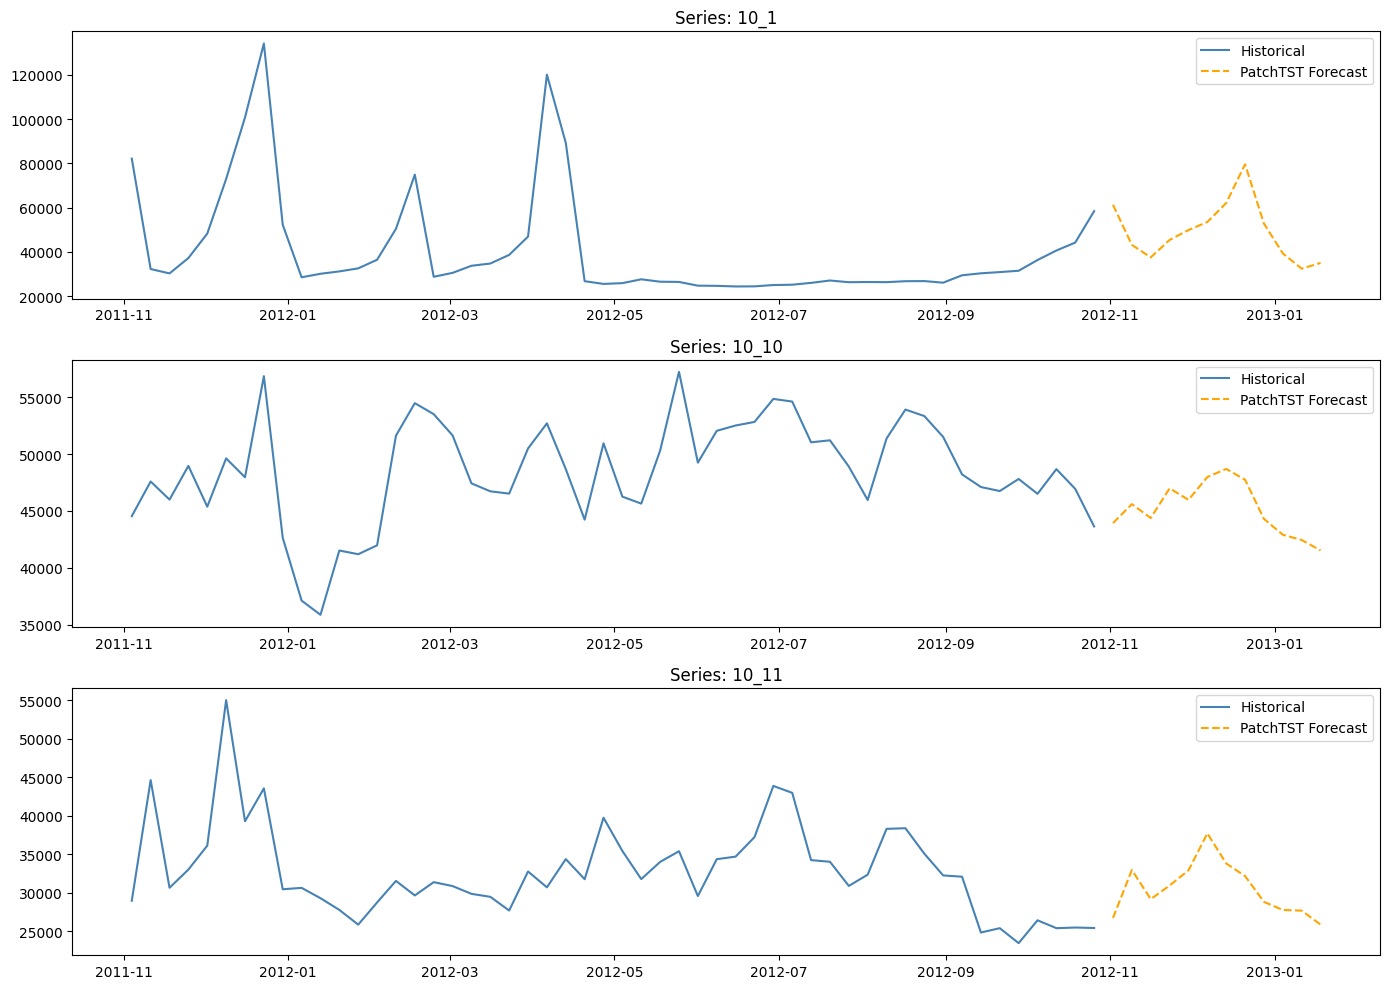

In [ ]:
sample_ids = forecasts_final['unique_id'].unique()[:3]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, uid in zip(axes, sample_ids):
    hist = train_full_filtered[train_full_filtered['unique_id'] == uid].tail(52)
    fc = forecasts_final[forecasts_final['unique_id'] == uid]

    ax.plot(hist['ds'], hist['y'], label='Historical', color='steelblue')
    ax.plot(fc['ds'], fc['PatchTST'], label='PatchTST Forecast', color='orange', linestyle='--')
    ax.set_title(f'Series: {uid}')
    ax.legend()

plt.tight_layout()
plt.show()

## 10. შეჯამება

PatchTST-ის სამი კონფიგურაცია ვცადეთ WandB-ზე ლოგირებით:

- **Baseline** — patch_len=8, 3 encoder layers, hidden=128
- **Larger Patch** — patch_len=16 (უფრო ცოტა tokens, უფრო დიდი receptive field)
- **Deeper** — 6 encoder layers, hidden=256, 8 attention heads

**საუკეთესო:** Deeper კონფიგი — val WMAE **1420.44**. მოდელის capacity-ის გაზრდამ დაეხმარა, overfitting-ი არ გაჩნდა.

Final model გატრენინგდა 1600 steps-ით მთელ ტრეინინგ სეტზე (train + val), შევინახე Drive-ზე pickle-ად და WandB Artifact-ად. 2934 (Store, Dept) time series-ს ერთი global transformer სწავლობს.

**შედარება N-BEATS-თან:**  
PatchTST (1420) და N-BEATS (1378) ერთმანეთს ძალიან ახლოს არიან — ორივე global DL model. N-BEATS-ის feed-forward simplicity აქ თითქმის იმდენივე კარგ შედეგს გვაძლევს, რამდენიც transformer-ის attention. Walmart-ის სპეციფიკა (მოკლე series, ცხადი სეზონურობა) არ ავლენს PatchTST-ის უპირატესობას სრულად.

**ყველა შენი 4 მოდელის შედარება:**

| Model | Category | Logging | Val WMAE |
|-------|----------|---------|----------|
| XGBoost | Tree-based | MLflow/DagsHub | 769.75 |
| N-BEATS | DL (feed-forward) | WandB | 1378.04 |
| PatchTST | DL (transformer) | WandB | 1420.44 |
| ARIMA/SARIMA | Classical | MLflow/DagsHub | 7012.96 (top 5 series only) |
